In [1]:
import pandas as pd
import numpy as np
import json
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# mapping from loyfer cell types to tabula cell types
loyfer_to_tabula_cell_types = json.load(
    open("../Data/rrbs_experiment/loyfer_to_tabula_cell_types.json", "r")
)
loyfer_to_tabula_cell_types = {
    loyfer.replace(",", "").lower(): [
        tabula.replace(",", "").lower() for tabula in tabula_list
    ]
    for loyfer, tabula_list in loyfer_to_tabula_cell_types.items()
}

In [3]:
cfsort_to_tabula_tissues = json.load(
    open("../Data/rrbs_experiment/cfsort_to_tabula_tissues_mapping.json", "r")
)

In [4]:
cfsort_tissues_tabula_name = sorted(
    elt["tabula_sapiens_name"] for elt in cfsort_to_tabula_tissues
)
cfsort_tissues_tabula_name = [e for e in cfsort_tissues_tabula_name if e != "NA"]

In [5]:
ts_tissue_agg = {
    "bladder": ["bladder organ"],
    "fat": ["adipose tissue", "brown adipose tissue", "subcutaneous adipose tissue"],
    "heart": [
        "heart",
        "heart right ventricle",
        "cardiac atrium",
        "cardiac ventricle",
        "right cardiac atrium",
    ],
    "kidney": ["cortex of kidney", "kidney"],
    "liver": ["liver"],
    "lung": ["lung"],
    "muscle": [
        "muscle of abdomen",
        "muscle of pelvic diaphragm",
    ],
    "ovary": ["left ovary", "ovary", "right ovary"],
    "pancreas": ["endocrine pancreas", "exocrine pancreas"],
    "prostate": ["prostate gland"],
    "salivary gland": ["parotid gland", "sublingual gland", "submandibular gland"],
    "skin": ["skin of abdomen", "skin of body", "skin of chest", "buccal mucosa"],
    "small intestine": ["duodenum", "ileum", "jejunum", "small intestine"],
    "spleen": ["spleen"],
    "stomach": [
        "mucosa of stomach",
        "muscularis mucosae of stomach",
        "stomach",
        "stomach smooth muscle",
    ],
    "testis": ["testis"],
    "uterus": ["uterus", "endometrium", "myometrium"],
    "vasculature": [
        "abdominal aorta",
        "aorta",
        "thoracic aorta",
        "vasculature",
        "coronary artery",
        "left coronary artery",
        "inferior vena cava",
    ],
}
reverse_ts_tissue_agg = {v: k for k, v_list in ts_tissue_agg.items() for v in v_list}

In [6]:
ts_counts_df = pd.read_csv(
    "../Data/rrbs_experiment/tabula_sapiens_cell_counts_by_tissue_and_donor.csv"
)
ts_counts_df.columns = ts_counts_df.columns.str.replace(",", "").str.lower()

In [7]:
# only keep the tissues that are in cfsort_tissues
ts_counts_df["tissue"] = ts_counts_df["tissue"].str.lower()
ts_counts_df["tissue"] = ts_counts_df["tissue"].map(
    lambda x: reverse_ts_tissue_agg.get(x, x)
)
ts_counts_df = ts_counts_df[ts_counts_df["tissue"].isin(cfsort_tissues_tabula_name)]

In [8]:
# create a count df with loyfer cell types instead of tabula cell types
loyfer_counts_df = ts_counts_df[["tissue", "donor_id"]].copy()
for loyfer_cell_type, tabula_cell_types in loyfer_to_tabula_cell_types.items():
    loyfer_counts_df[loyfer_cell_type] = ts_counts_df[tabula_cell_types].sum(axis=1)

# drop the lines where all loyfer cell types are 0
loyfer_counts_df = loyfer_counts_df[~(loyfer_counts_df.iloc[:, 2:] == 0).all(axis=1)]

In [9]:
loyfer_ratios_df = loyfer_counts_df.copy()
ctypes_list = list(loyfer_to_tabula_cell_types.keys())
loyfer_ratios_df[ctypes_list] = loyfer_ratios_df[ctypes_list].astype(float)
loyfer_ratios_df.iloc[:, 2:] = loyfer_ratios_df.iloc[:, 2:].div(
    loyfer_ratios_df.iloc[:, 2:].sum(axis=1), axis=0
)

In [10]:
loyfer_counts_df["tissue"].value_counts()

tissue
vasculature        14
fat                14
muscle             11
small intestine    10
skin                9
ovary               8
heart               8
salivary gland      7
bladder             6
spleen              6
stomach             6
uterus              5
liver               4
pancreas            4
lung                4
prostate            3
kidney              2
testis              1
Name: count, dtype: int64

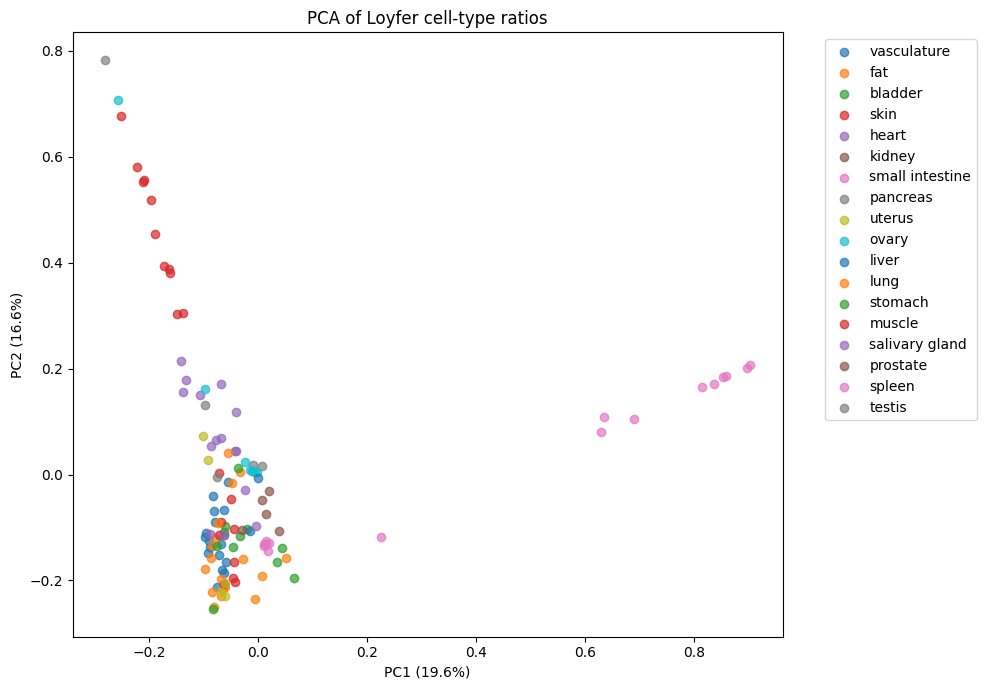

In [11]:
pca = PCA(n_components=2)
X = loyfer_ratios_df[ctypes_list].values
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
tissues = loyfer_ratios_df["tissue"].unique()
for tissue in tissues:
    mask = loyfer_ratios_df["tissue"] == tissue
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=tissue, alpha=0.7)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA of Loyfer cell-type ratios")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/home/nathan/.cache/pypoetry/virtualenvs/syto-eOjiV2TE-py3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


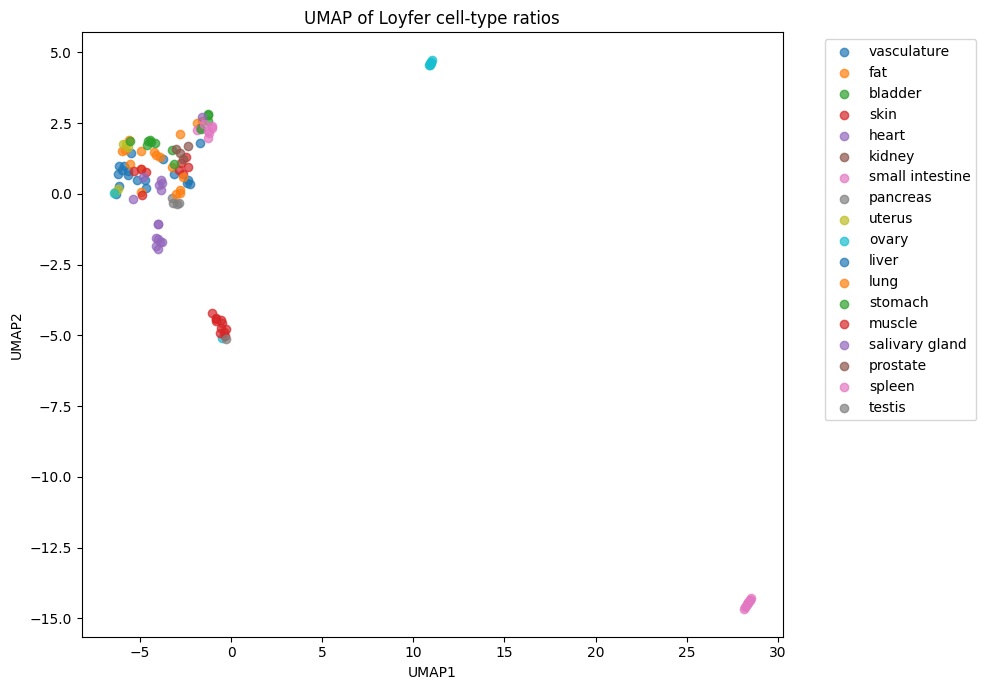

In [12]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(loyfer_ratios_df[ctypes_list].values)

fig, ax = plt.subplots(figsize=(10, 7))
for tissue in loyfer_ratios_df["tissue"].unique():
    mask = loyfer_ratios_df["tissue"] == tissue
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], label=tissue, alpha=0.7)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP of Loyfer cell-type ratios")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
loyfer_ratios_df

,tissue,donor_id,adipocytes,bladder-ep,blood-b,blood-granul,blood-mono+macro,blood-nk,blood-t,breast-basal-ep,...,pancreas-acinar,pancreas-alpha,pancreas-beta,pancreas-delta,pancreas-duct,prostate-ep,skeletal-musc,small-int-ep,smooth-musc,unmapped
0,vasculature,TSP14,0.000000,0.0,0.000000,0.026393,0.093842,0.014663,0.181818,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058651,0.114370
1,fat,TSP10,0.004811,0.0,0.005073,0.002887,0.091585,0.003062,0.060882,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002187,0.025892
2,fat,TSP14,0.034561,0.0,0.003142,0.103683,0.084657,0.000349,0.093908,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004015,0.035957
3,fat,TSP2,0.008696,0.0,0.460870,0.000000,0.000000,0.008696,0.478261,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,fat,TSP21,0.031340,0.0,0.310150,0.000368,0.099111,0.003189,0.313523,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001840,0.001165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,testis,TSP25,0.000000,0.0,0.000133,0.000133,0.007454,0.000000,0.000666,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.984560
182,vasculature,TSP14,0.000000,0.0,0.003597,0.028777,0.089928,0.025180,0.183453,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.079137,0.017986
183,vasculature,TSP25,0.000000,0.0,0.004274,0.134921,0.213370,0.014042,0.118437,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009768,0.010684
196,uterus,TSP4,0.000000,0.0,0.010471,0.000000,0.109948,0.028272,0.105759,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002094,0.019895


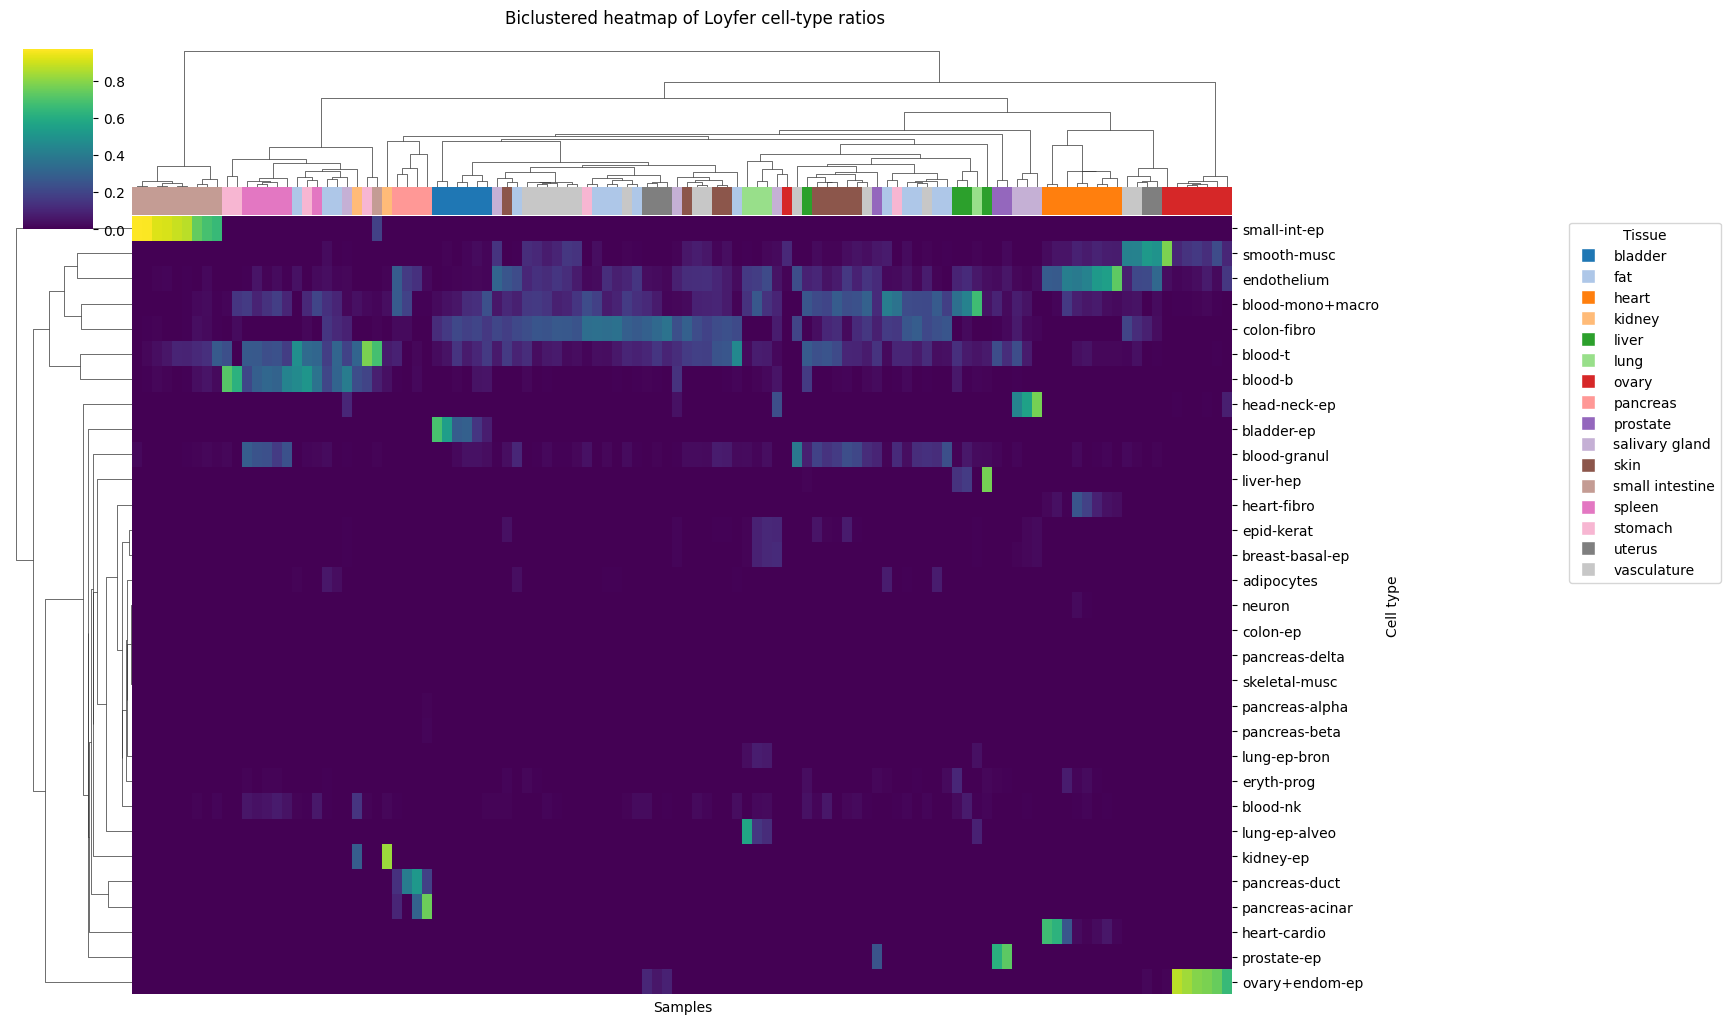

In [14]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

"tissue_distribution"
exclude_ctypes = ["unmapped", "dermal-fibro"]
ctypes_filtered = [c for c in ctypes_list if c not in exclude_ctypes]

filtered_df = loyfer_ratios_df[~loyfer_ratios_df["tissue"].isin(["testis", "muscle"])]

heatmap_df = filtered_df.set_index(["tissue", "donor_id"])[ctypes_filtered].T

row_linkage = linkage(pdist(heatmap_df.values), method="ward", optimal_ordering=True)
col_linkage = linkage(pdist(heatmap_df.values.T), method="ward", optimal_ordering=True)

# build a consistent tissue-to-color mapping
tissues_sorted = sorted(heatmap_df.columns.get_level_values("tissue").unique())
palette = sns.color_palette("tab20", n_colors=len(tissues_sorted))
tissue_color_map = dict(zip(tissues_sorted, palette))

col_colors = heatmap_df.columns.get_level_values("tissue").map(tissue_color_map)

g = sns.clustermap(
    heatmap_df,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    cmap="viridis",
    figsize=(14, 10),
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.15),
)
g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Cell type")
g.fig.suptitle("Biclustered heatmap of Loyfer cell-type ratios", y=1.02)

# legend uses the same tissue_color_map
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor=tissue_color_map[t],
        markersize=10,
        label=t,
    )
    for t in tissues_sorted
]
g.ax_heatmap.legend(
    handles=handles, title="Tissue", bbox_to_anchor=(1.3, 1), loc="upper left"
)

plt.show()

In [15]:
loyfer_ratios_df.loc[
    (loyfer_ratios_df["tissue"] == "ovary") & (loyfer_ratios_df["ovary+endom-ep"] < 0.1)
].T

,129,130
tissue,ovary,ovary
donor_id,TSP28,TSP30
adipocytes,0.0,0.0
bladder-ep,0.0,0.0
blood-b,0.000893,0.001507
blood-granul,0.0,0.0
blood-mono+macro,0.0,0.0
blood-nk,0.0,0.0
blood-t,0.0,0.0
breast-basal-ep,0.0,0.0


In [16]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

# compute ts_ratios
ts_ratios_df = ts_counts_df.copy()
ts_ctype_list = [
    col for col in ts_ratios_df.columns if col not in ["tissue", "donor_id"]
]
ts_ratios_df[ts_ctype_list] = ts_ratios_df[ts_ctype_list].astype(float)
ts_ratios_df[ts_ctype_list] = ts_ratios_df[ts_ctype_list].div(
    ts_ratios_df[ts_ctype_list].sum(axis=1), axis=0
)

# compute the number of cells from each ts_cell_type and do not use the ones that are in the last x quantile
count_per_ts_ctype = ts_counts_df[ts_ctype_list].sum()
ts_ctype_list_with_non_zero_counts = count_per_ts_ctype[
    count_per_ts_ctype > 0
].index.tolist()
quantile_threshold = 0.75
count_threshold = count_per_ts_ctype[ts_ctype_list_with_non_zero_counts].quantile(
    quantile_threshold
)
ts_ctype_list_with_non_zero_counts_x_quantile = count_per_ts_ctype[
    count_per_ts_ctype >= count_threshold
].index.tolist()

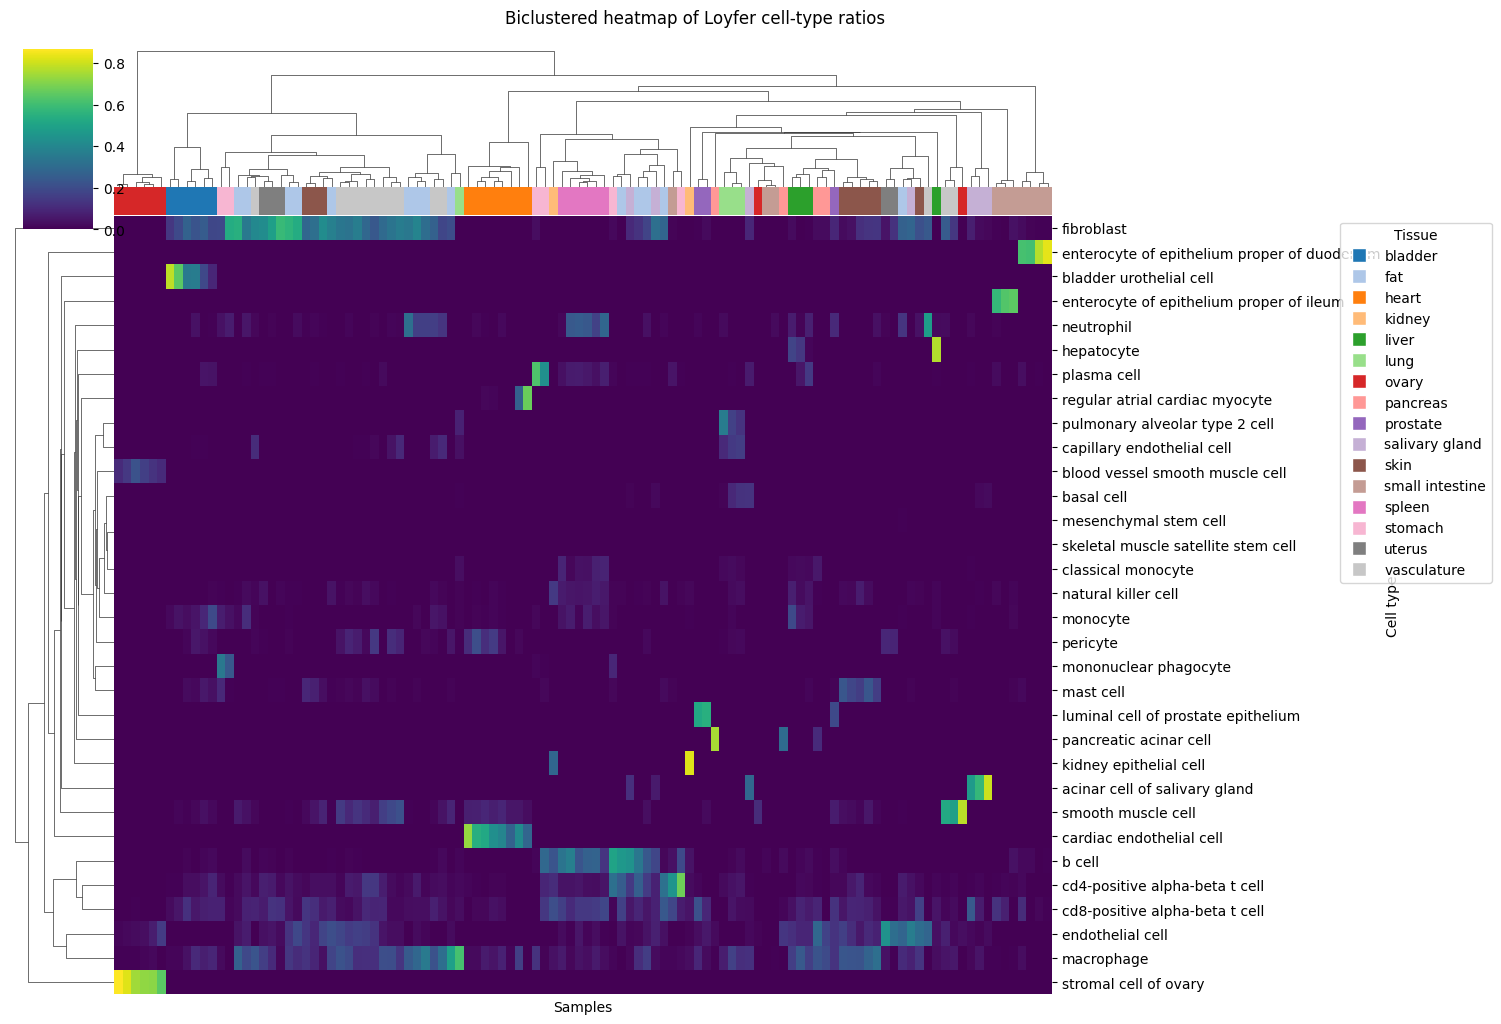

In [17]:
ts_ctype_filtered = [
    c for c in ts_ctype_list_with_non_zero_counts_x_quantile if c not in exclude_ctypes
]

filtered_df = ts_ratios_df.loc[
    ~ts_ratios_df["tissue"].isin(["testis", "muscle"]),
    ts_ctype_filtered + ["tissue", "donor_id"],
]

heatmap_df = filtered_df.set_index(["tissue", "donor_id"])[ts_ctype_filtered].T

row_linkage = linkage(pdist(heatmap_df.values), method="ward", optimal_ordering=True)
col_linkage = linkage(pdist(heatmap_df.values.T), method="ward", optimal_ordering=True)

# build a consistent tissue-to-color mapping
tissues_sorted = sorted(heatmap_df.columns.get_level_values("tissue").unique())
palette = sns.color_palette("tab20", n_colors=len(tissues_sorted))
tissue_color_map = dict(zip(tissues_sorted, palette))

col_colors = heatmap_df.columns.get_level_values("tissue").map(tissue_color_map)

g = sns.clustermap(
    heatmap_df,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    cmap="viridis",
    figsize=(14, 10),
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.15),
)
g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Cell type")
g.fig.suptitle("Biclustered heatmap of Loyfer cell-type ratios", y=1.02)

# legend uses the same tissue_color_map
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor=tissue_color_map[t],
        markersize=10,
        label=t,
    )
    for t in tissues_sorted
]
g.ax_heatmap.legend(
    handles=handles, title="Tissue", bbox_to_anchor=(1.3, 1), loc="upper left"
)

plt.show()

In [18]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import entropy


def cluster_and_entropy(
    df,
    ctype_cols,
    label_col="tissue",
    exclude_tissues=["testis", "muscle"],
    exclude_ctypes=["unmapped", "dermal-fibro"],
):
    """Cluster rows into n_tissues leaves and compute tissue-entropy per leaf."""
    filtered = df[~df[label_col].isin(exclude_tissues)].copy()
    ctype_cols = [c for c in ctype_cols if c not in exclude_ctypes]
    X = filtered[ctype_cols].values
    tissues = filtered[label_col].values
    n_clusters = filtered[label_col].nunique()

    Z = linkage(pdist(X), method="ward", optimal_ordering=True)
    labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    results = []
    for c in sorted(np.unique(labels)):
        mask = labels == c
        tissue_counts = pd.Series(tissues[mask]).value_counts(normalize=True).round(4)
        results.append(
            {
                "cluster": c,
                "size": mask.sum(),
                "entropy": entropy(tissue_counts),
                "dominant_tissue": tissue_counts.idxmax(),
                "dominant_ratio": tissue_counts.max(),
                "tissue_distribution": tissue_counts.to_dict(),
            }
        )
    return pd.DataFrame(results)


# --- Loyfer cell types ---
print("=== Loyfer cell-type ratios ===")
loyfer_entropy_df = cluster_and_entropy(loyfer_ratios_df, ctypes_list)
display(
    loyfer_entropy_df[
        [
            "cluster",
            "size",
            "entropy",
            "dominant_tissue",
            "dominant_ratio",
            "tissue_distribution",
        ]
    ]
)
print(f"Sum of cluster entropies: {loyfer_entropy_df['entropy'].sum():.4f}")

# --- Tabula Sapiens cell types (top quantile) ---
print("\n=== Tabula Sapiens cell-type ratios (top quantile) ===")
ts_entropy_df = cluster_and_entropy(
    ts_ratios_df, ts_ctype_list_with_non_zero_counts_x_quantile
)
display(
    ts_entropy_df[
        [
            "cluster",
            "size",
            "entropy",
            "dominant_tissue",
            "dominant_ratio",
            "tissue_distribution",
        ]
    ]
)
print(f"Sum of cluster entropies: {ts_entropy_df['entropy'].sum():.4f}")

=== Loyfer cell-type ratios ===


,cluster,size,entropy,dominant_tissue,dominant_ratio,tissue_distribution
0,1,9,0.000000,small intestine,1.0000,{'small intestine': 1.0}
1,2,14,1.400244,spleen,0.4286,"{'spleen': 0.4286, 'fat': 0.2143, 'stomach': 0..."
2,3,2,0.693147,small intestine,0.5000,"{'small intestine': 0.5, 'stomach': 0.5}"
3,4,4,0.000000,pancreas,1.0000,{'pancreas': 1.0}
4,5,1,0.000000,kidney,1.0000,{'kidney': 1.0}
5,6,2,0.000000,bladder,1.0000,{'bladder': 1.0}
6,7,29,1.770859,vasculature,0.3103,"{'vasculature': 0.3103, 'fat': 0.2069, 'bladde..."
7,8,5,0.950271,lung,0.6000,"{'lung': 0.6, 'ovary': 0.2, 'salivary gland': ..."
8,9,19,1.750289,fat,0.2632,"{'fat': 0.2632, 'skin': 0.2632, 'vasculature':..."
9,10,1,0.000000,liver,1.0000,{'liver': 1.0}


Sum of cluster entropies: 7.6197

=== Tabula Sapiens cell-type ratios (top quantile) ===


,cluster,size,entropy,dominant_tissue,dominant_ratio,tissue_distribution
0,1,6,0.000000,ovary,1.0000,{'ovary': 1.0}
1,2,6,0.000000,bladder,1.0000,{'bladder': 1.0}
2,3,22,1.463787,vasculature,0.4091,"{'vasculature': 0.4091, 'fat': 0.2273, 'uterus..."
3,4,7,0.955749,fat,0.5714,"{'fat': 0.5714, 'vasculature': 0.2857, 'lung':..."
4,5,8,0.000000,heart,1.0000,{'heart': 1.0}
5,6,2,0.000000,stomach,1.0000,{'stomach': 1.0}
6,7,16,1.580819,spleen,0.3750,"{'spleen': 0.375, 'fat': 0.25, 'salivary gland..."
7,8,2,0.000000,prostate,1.0000,{'prostate': 1.0}
8,9,25,2.226998,skin,0.2400,"{'skin': 0.24, 'liver': 0.12, 'pancreas': 0.12..."
9,10,1,0.000000,pancreas,1.0000,{'pancreas': 1.0}


Sum of cluster entropies: 6.8638


In [21]:
# Now we compute the clustering until all clusters have a single tissue type.
# A cluster that is already pure is never further divided.
# Then for all clusters of size > 1, we compute the ratio of the size of the cluster
# over the total number of samples in the dataset of the dominant tissue in that cluster.

from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import pdist


def cluster_until_pure(
    df,
    ctype_cols,
    label_col="tissue",
    exclude_tissues=["testis", "muscle"],
    exclude_ctypes=["unmapped", "dermal-fibro"],
):
    """Walk the dendrogram top-down, stopping as soon as a subtree is tissue-pure."""
    filtered = df[~df[label_col].isin(exclude_tissues)].copy().reset_index(drop=True)
    ctype_cols = [c for c in ctype_cols if c not in exclude_ctypes]
    X = filtered[ctype_cols].values
    tissues = filtered[label_col].values
    tissue_total_counts = pd.Series(tissues).value_counts()

    Z = linkage(pdist(X), method="ward", optimal_ordering=True)
    root = to_tree(Z)

    pure_clusters = []

    def get_leaf_ids(node):
        if node.is_leaf():
            return [node.id]
        return get_leaf_ids(node.get_left()) + get_leaf_ids(node.get_right())

    def recurse(node):
        ids = get_leaf_ids(node)
        node_tissues = set(tissues[i] for i in ids)
        if len(node_tissues) == 1:
            pure_clusters.append(ids)
        else:
            recurse(node.get_left())
            recurse(node.get_right())

    recurse(root)

    print(f"Number of pure clusters: {len(pure_clusters)}")

    results = []
    for i, ids in enumerate(pure_clusters):
        tissue = tissues[ids[0]]
        size = len(ids)
        recovery_ratio = size / tissue_total_counts[tissue]
        results.append(
            {
                "cluster": i + 1,
                "tissue": tissue,
                "size": size,
                "total_tissue_samples": tissue_total_counts[tissue],
                "recovery_ratio": round(recovery_ratio, 4),
            }
        )

    results_df = pd.DataFrame(results)
    results_df = results_df[results_df["size"] > 1].reset_index(drop=True)
    return results_df


# --- Loyfer cell types ---
print("=== Loyfer cell-type ratios ===")
loyfer_pure_df = cluster_until_pure(loyfer_ratios_df, ctypes_list)
display(loyfer_pure_df)

# --- Tabula Sapiens cell types (top quantile) ---
print("\n=== Tabula Sapiens cell-type ratios (top quantile) ===")
ts_pure_df = cluster_until_pure(
    ts_ratios_df, ts_ctype_list_with_non_zero_counts_x_quantile
)
display(ts_pure_df)

=== Loyfer cell-type ratios ===
Number of pure clusters: 60


,cluster,tissue,size,total_tissue_samples,recovery_ratio
0,1,small intestine,9,10,0.9000
1,2,stomach,2,6,0.3333
2,3,spleen,5,6,0.8333
3,7,fat,2,14,0.1429
4,13,pancreas,4,4,1.0000
5,14,bladder,2,6,0.3333
6,15,bladder,4,6,0.6667
7,19,vasculature,6,14,0.4286
8,22,fat,2,14,0.1429
9,25,uterus,3,5,0.6000



=== Tabula Sapiens cell-type ratios (top quantile) ===
Number of pure clusters: 53


,cluster,tissue,size,total_tissue_samples,recovery_ratio
0,1,ovary,6,8,0.7500
1,2,bladder,6,6,1.0000
2,3,stomach,2,6,0.3333
3,7,uterus,2,5,0.4000
4,9,fat,2,14,0.1429
5,10,skin,2,9,0.2222
6,13,vasculature,5,14,0.3571
7,14,vasculature,3,14,0.2143
8,15,fat,3,14,0.2143
9,16,vasculature,2,14,0.1429


In [23]:
# Aggregate the two previous dataframes by showing for each tissue, the size of the biggest pure cluster for that tissue, and the recovery ratio of that cluster: one set of columns for loyfer and one set of columns for tabula.

loyfer_best = loyfer_pure_df.loc[loyfer_pure_df.groupby("tissue")["size"].idxmax()][
    ["tissue", "size", "recovery_ratio"]
].rename(
    columns={
        "size": "loyfer_max_cluster_size",
        "recovery_ratio": "loyfer_recovery_ratio",
    }
)

ts_best = ts_pure_df.loc[ts_pure_df.groupby("tissue")["size"].idxmax()][
    ["tissue", "size", "recovery_ratio"]
].rename(columns={"size": "ts_max_cluster_size", "recovery_ratio": "ts_recovery_ratio"})

comparison_df = (
    loyfer_best.merge(ts_best, on="tissue", how="outer")
    .sort_values("tissue")
    .reset_index(drop=True)
)
display(comparison_df)

,tissue,loyfer_max_cluster_size,loyfer_recovery_ratio,ts_max_cluster_size,ts_recovery_ratio
0,bladder,4,0.6667,6,1.0000
1,fat,2,0.1429,3,0.2143
2,heart,8,1.0000,8,1.0000
3,liver,2,0.5000,3,0.7500
4,lung,2,0.5000,3,0.7500
5,ovary,6,0.7500,6,0.7500
6,pancreas,4,1.0000,2,0.5000
7,prostate,2,0.6667,2,0.6667
8,salivary gland,3,0.4286,3,0.4286
9,skin,3,0.3333,5,0.5556


In [24]:
(comparison_df["loyfer_recovery_ratio"] > comparison_df["ts_recovery_ratio"]).sum()

np.int64(4)

In [25]:
(comparison_df["loyfer_recovery_ratio"] < comparison_df["ts_recovery_ratio"]).sum()

np.int64(6)

In [27]:
comparison_df["loyfer_max_cluster_size"].sum(), comparison_df[
    "ts_max_cluster_size"
].sum()

(np.int64(61), np.int64(60))